## Training Logistic Regression with Scikit-Learn

Scikit-learn handles multiclass classification "off the shelf."

### Key Concepts

* **Optimized Implementation:** Scikit-learn provides a highly efficient version of logistic regression compared to manual implementations like Adaline.
* **Multiclass Support:** It automatically handles more than two classes using two primary strategies:
    * **OvR (One-vs-Rest):** The model trains a separate classifier for each class.
    * **Multinomial:** Also known as *Softmax Regression*. This is the **default** and recommended setting for mutually exclusive classes.
* **Mutually Exclusive Classes:** This refers to datasets (like Iris) where each sample belongs to exactly **one** category, as opposed to "multilabel" classification where a sample could belong to several.

In [17]:
from google.colab import drive
drive.mount('/content/drive')

%run '/content/drive/MyDrive/Repos/MachineLearning-ML001/helper/helper.ipynb'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [18]:
import numpy as np
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

iris = datasets.load_iris()
X = iris.data[:, [2, 3]]
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=1, stratify=y)

sc = StandardScaler()
sc.fit(X_train)
X_train_std = sc.transform(X_train)
X_test_std = sc.transform(X_test)

In [19]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(C=100.0, solver='lbfgs', multi_class='ovr')
lr.fit(X_train_std, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(C=100.0, multi_class='ovr')

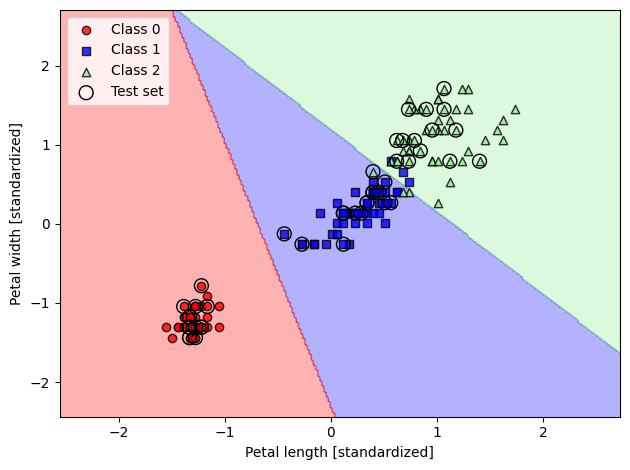

In [20]:
X_combined_std = np.vstack((X_train_std, X_test_std))
y_combined = np.hstack((y_train, y_test))

plot_decision_regions(X_combined_std, y_combined, classifier=lr, test_idx=range(105, 150))
plt.xlabel('Petal length [standardized]')
plt.ylabel('Petal width [standardized]')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

In [21]:
lr.predict_proba(X_test_std[:3, :])

array([[6.63770505e-09, 1.44747233e-01, 8.55252760e-01],
       [8.34031210e-01, 1.65968790e-01, 3.20815954e-13],
       [8.48822884e-01, 1.51177116e-01, 2.57998350e-14]])

In [22]:
lr.predict_proba(X_test_std[:3, :]).sum(axis=1)

array([1., 1., 1.])

In [23]:
lr.predict_proba(X_test_std[:3, :]).argmax(axis=1)

array([2, 0, 0])

In [24]:
lr.predict(X_test_std[:3, :])

array([2, 0, 0])

In [28]:
lr.predict(X_test_std[0, :].reshape(1, - 1))

array([2])